# LED Charge-Up Analysis

## Overview

This notebook analyzes the LED charge-up process and demonstrates performance improvements achieved through running LEDs at high current.

### What is LED Charge-Up?

LED charge-up is a conditioning process where LEDs are operated at high current levels to improve their final settling behavior and output power stability. This process reduces drift and achieves better performance characteristics over long time scales.

### Key Metrics

- **60to300**: Primary settling metric measuring the percentage change in LED output from 60 seconds to 300 seconds after turn-on. Lower values indicate better stability.
- **Precharge [mA*s]**: The charge delivered during the conditioning phase (current × time)
- **mA*s/final_mA**: Normalization factor showing charge delivered per final operating current. this is also how nominal precharging is described

### Notebook Workflow

1. **Data Processing**: Load and analyze LED performance data from multiple test runs
2. **Metric Calculation**: Calculate settling metrics for each LED configuration
3. **Comparison Analysis**: Visualize before/after improvements from charge-up process

---

## 1. Import Dependencies



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from tqdm import tqdm
from os.path import basename
from scipy.io import loadmat
from srcs_utils import *
import analysis_export_utils as ex
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
%matplotlib widget
plt.rcParams.update({'figure.max_open_warning': 50})


## 2. Data Processing Functions

### Main Data Processing Function

This function:
1. Loads parquet files from the `data/precharge/` directory
2. Processes LED data for different bands (4, 5, 6), banks (1, 2), and flux levels
3. Calculates settling metrics for each configuration
4. Generates comparison plots and exports to PowerPoint

**Key Parameters:**
- `foi` (flux of interest): [0.3, 60] e-/pix/s - LED flux levels to analyze
- `boi` (band of interest): [4, 5, 6] - Detector bands
- `bankofint`: [1, 2] - LED banks
- `norm_to`: 299 seconds - Normalization time for settling calculations

In [2]:

m = None

def reprocess_data():
    global m
    dataset = dict()

    from glob import glob
    for f in glob('data/precharge/*.parquet'):
        k = f.replace('.parquet', '')
        if ('chargeup' in k) or ('precharge' in k.lower()):
            dataset[basename(k)] = pd.read_parquet(f)



    aside_pc = [k for k in dataset.keys() if k.startswith('A')]


    percent = True
    ex.create_ppt("templates/rst_scipa.pptx")
    metrics = list()
    norm_to = 299
    prebank = 0
    preband = 0
    precharget = 0
    prechargec = 0
    plt.close('all')
    p = 1
    for foi in [0.3, 60]:
        for boi in [4, 5, 6]:
            #plt.figure()
            for bankofint in [1, 2]:

                fig = plt.figure(dpi=130)
                fig.set_size_inches(w=10, h=6.25)

                for k in dataset.keys():# aside_pc: # ['A STV 200K chargeup', 'B STV 200K chargeup']:# dataset.keys(): #['B TV2 200K Precharge r3', 'B TV2 200K sci mon r3']:#['B TV1 200K sci mon', 'B TV2 200K Precharge r1', 'B TV2 200K Precharge r2', 'B TV2 200K Precharge r3', 'B TV2 200K Precharge r4', 'B TV2 200K Precharge r5', 'B TV2 200K sci mon r1', 'B TV2 200K sci mon r2',  'B TV2 200K sci mon r3']:#, 'B TVAC2 Ambient Pre-Pumpdown']: #
                    #for k in ['B TV2 200K sci mon r3']:
                    #print(f'processing {k}')
                    df = dataset[k]
                    print(k)
                    side = k[0]

                    allinfo = list()
                    darkv = get_wfi_darkv(df, legacy=True)
                    print(darkv)

                    anyc, oniloc = process_wfi_changes(df)
                    anyc = anyc.ffill()
                    this_set = dict()

                    for i in range(len(anyc)):
                        st = anyc.index[i]
                        if i >= len(anyc.index) - 1:
                            en = anyc.index[-1]
                        else:
                            en = anyc.index[i+1]

                        data = df.loc[(st+pd.Timedelta(seconds=1)):(en - pd.Timedelta(seconds=0))]
                        if (len(data) > 15) and (anyc.iloc[i].on):

                            info = get_info_wfi(data, side=side, cfg=anyc.iloc[i])
                            band = info['band']
                            bank = info['bank']
                            cur = info['current']
                            code = info['code']
                            if not ((prebank == bank) and (preband == band)):
                                precharget = 0
                                prechargec = 0

                            #if (info['bank'] == b and (info['code'] == c) and (info['band']  == 4)):
                            if (len(data) > 15) and (band != 0):
                                #print(f'{k}:side={side}, band={band}, bank={bank}, code={code}')
                                flux = code_to_flux(side, band, bank, code)

                                if flux < 10:
                                    flux = round(flux, 1)
                                else:
                                    flux = round(flux, 0)

                                #print(flux)
                                ledinfo = f'Side{side}|Band{band}|Bank{bank}@{flux}for{code}[{i}]{darkv[1]:.5f}'
                                #print(ledinfo)
                                if (bank == bankofint) & (band == boi) and (flux == foi) and (prechargec >= 0):#5284
                                    pc_fma = prechargec*precharget/(info['current']*1e3)
                                    old_label = f'{k[-2:]} [{pc_fma:.0f}mA*s/fmA]'
                                    print(k)
                                    label = f'Side{side}[@{flux:.0f}e-/pix/s|{cur*1e3:.2f}mA|{pc_fma:.0f}mA/fmA]'
                                    metric,pd1,pd2 = metric_calc_wfi(data, darkv, p, '', label, info=info, norm_to=norm_to, side=side, plot=True, percent=percent, rolling=0)
                                    for key,val in info.items():
                                        metric[key] = val
                                    metric['setname'] = k
                                    metric['precharge [s]'] = precharget
                                    metric['precharge [mA]'] = prechargec
                                    metric['precharge [mA*s]'] = prechargec*precharget
                                    metric['mA*s/final_mA'] = pc_fma
                                    metric['flux'] = flux
                                    metric['pd'] = p
                                    metric['PD1 data'] = pd1
                                    metric['PD2 data'] = pd2
                                    metrics.append(metric)
                                lastt = (data.index[-1] - data.index[0]).total_seconds()
                                precharget = lastt
                                prechargec = info['current']*1e3
                                prebank = bank
                                preband = band

                        elif (not anyc.iloc[i].on) and (len(data) > 6):
                            #print('alternate dark found')
                            # the drift is so small that this doesn't make a big difference
                            darkv = get_wfi_darkv(data, legacy=True)

                plt.legend()

                if foi > 1000:
                    plt.ylim([-.1, .05])
                elif foi == 60:
                    plt.ylim([None, .5])
                else:
                    plt.ylim([-2, 2])


                plt.ylabel(f'LED Settling [%]')
                plt.xlabel('Time [seconds]')
                plt.grid(True)
                plt.gcf().set_tight_layout(True)
                ex.add_figure(title=f'Band {boi} Bank {bankofint} PD{p}@ {foi} e-/pix/s', xd=10, yd=6.25, x0=1.67, y0=1)

                #plt.close()

        m = pd.DataFrame(metrics)

        save_dropdown = widgets.Dropdown(
            options=['Yes', 'No'],
            value='No',
            description='Save metrics?',
            disabled=False,
        )
        save_button = widgets.Button(description="Confirm")
        save_output = widgets.Output()

        def on_save_button_clicked(b):
            with save_output:
                clear_output()
                if save_dropdown.value == 'Yes':
                    m.to_hdf('data/precharge/metrics.h5', key='metrics', mode='w')
                    print("Metrics saved to data/precharge/metrics.h5")
                else:
                    print("Metrics not saved")
                display(m)

        save_button.on_click(on_save_button_clicked)
        display(save_dropdown, save_button, save_output)

def load_existing_data():
    global m
    m = pd.read_hdf('data/precharge/metrics.h5', key='metrics')
    print("Metrics loaded from data/precharge/metrics/metrics.h5")
    display(m)

dropdown = widgets.Dropdown(
    options=['Reprocess data', 'Load existing data'],
    value='Load existing data',
    description='Action:',
    disabled=False,
)
button = widgets.Button(description="Execute")
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output()
        if dropdown.value == 'Reprocess data':
            reprocess_data()
        else:
            load_existing_data()

button.on_click(on_button_clicked)


## 3. Interactive Data Loading

Use the dropdown and button below to either:
- **Reprocess data**: Analyze all raw data files (takes several minutes)
- **Load existing data**: Load previously calculated metrics (fast)

In [3]:
display(dropdown, button, output)

Dropdown(description='Action:', index=1, options=('Reprocess data', 'Load existing data'), value='Load existin…

Button(description='Execute', style=ButtonStyle())

Output()

## 4. Comparison Analysis

### Filter Data by Test Campaign

The metrics dataframe contains data from multiple test campaigns:
- **SCIPA TVAC**: Side B stability test at 200K
- **TV2**: Thermal vacuum test 2
- **STV**: Additional stability test on Side A

The following cells generate before/after comparison plots for different test campaigns.
Each plot shows the 60to300 settling metric for all LED configurations.

**How to interpret the plots:**
- Y-axis: Settling percentage (lower is better)
- Blue bars: Before charge-up (first run)
- Orange bars: After charge-up (conditioned state)
- Goal: Reduce settling by multiple orders. Band 5 < 0.5%, Band 6 < 0.2%

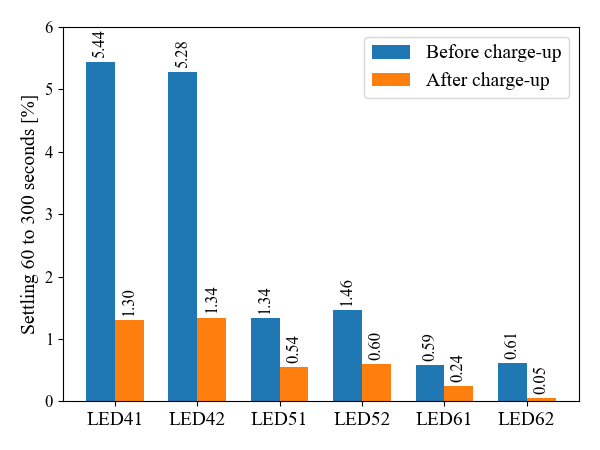

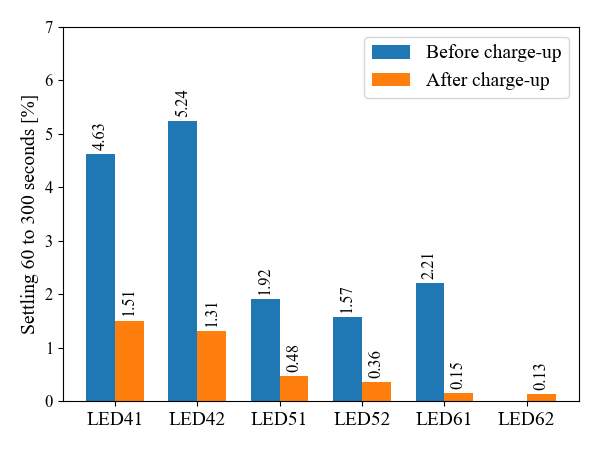

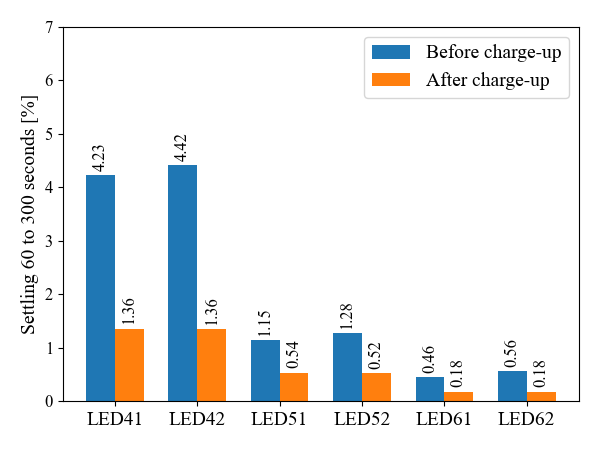

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

plt.close('all')
t = m
tv2 = t[((t.setname == 'B TV2 200K Precharge r1') | (t.setname == 'B TV2 200K Precharge r6')) & (t['precharge [s]'] == 0)]
stvA =  t[(t.setname == 'A STV 200K chargeup')]


scipa = t[t.setname == 'B STV 200K chargeup']


def plot_comparison(df, param, bands=[4, 5, 6], banks=[1, 2], title_prefix='SCIPA TVAC Side B LED Chargeup', ylabel=None, ylim=[0, None], l1='Before charge-up', l2='After charge-up'):
    if ylabel is None:
        ylabel = param
    led_labels = []
    before_values = []
    after_values = []

    for band in bands:
        for bank in banks:
            d = df[(df.band == band) & (df.bank == bank)]
            if len(d) >= 2:
                before = d[param].iloc[0]
                after = d[param].iloc[-1]
            led_labels.append(f'LED{band}{bank}')
            before_values.append(before)
            after_values.append(after)

    # Set up the bar plot
    x = np.arange(len(led_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4.5))
    rects1 = ax.bar(x - width/2, before_values, width, label=l1)
    rects2 = ax.bar(x + width/2, after_values, width, label=l2)

    # Customize the plot
    ax.set_ylabel(f'{ylabel}', fontsize=14)
    #ax.set_title(f'{title_prefix}: Before & After')
    ax.set_xticks(x)
    ax.set_xticklabels(led_labels, fontsize=14)
    ax.set_ylim(ylim)
    ax.legend(fontsize=14)

    # Add value labels on top of each bar
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', rotation=90, fontsize=12)

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

plt.close('all')
# sometimes I use m sometimes I use t, to have metrics (m) or tvac data (t)

# Usage examples:
plot_comparison(scipa, '60to300', title_prefix='', ylabel='Settling 60 to 300 seconds [%]', ylim=[0, 6])
plt.savefig('Chargeup.pdf',dpi=200)
plot_comparison(tv2, '60to300', title_prefix='WFI TVAC2 Side B LED Chargeup', ylabel='Settling 60 to 300 seconds [%]', ylim=[0, 7])
plot_comparison(stvA, '60to300', title_prefix='SCIPA TVAC Side A LED Chargeup', ylabel='Settling 60 to 300 seconds [%]', ylim=[0, 7])
